In [1]:
from pathlib import Path

import scarf

scarf.set_verbosity('WARNING')

scarf.fetch_dataset(
    'tenx_5K_pbmc_rnaseq',
    save_path='scarf_datasets',
    as_zarr=True,
)
ds = scarf.DataStore(
    'scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr',
    nthreads=4,
    min_features_per_cell=10,
)
ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito'],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
    reset_previous=True,
)

if 'RNA_UMAP1' not in ds.cells.columns:
    ds.mark_hvgs(min_cells=20, top_n=500, show_plot=False)
    ds.make_graph(feat_key='hvgs', k=11, dims=15, n_centroids=100)
    ds.run_umap(n_epochs=150, spread=5, min_dist=1, parallel=True)

In [2]:
gmt_path = Path('scarf_datasets/pbmc_signatures.gmt')
gmt_path.write_text(
    'T_cell\tna\tCD3D\tCD3E\tTRAC\tLTB\tIL7R\n'
    'B_cell\tna\tMS4A1\tCD79A\tCD37\tCD74\tHLA-DRA\n'
    'Myeloid\tna\tLST1\tS100A8\tS100A9\tCTSS\tFCER1G\n',
    encoding='utf-8',
)
gene_sets = scarf.read_gmt(gmt_path)
gene_sets

,source,target
0,T_cell,CD3D
1,T_cell,CD3E
2,T_cell,TRAC
3,T_cell,LTB
4,T_cell,IL7R
5,B_cell,MS4A1
6,B_cell,CD79A
7,B_cell,CD37
8,B_cell,CD74
9,B_cell,HLA-DRA


In [3]:
available = {str(name).upper() for name in ds.RNA.feats.fetch('names')}
(
    gene_sets.assign(
        matched=gene_sets['target'].str.upper().isin(available),
    )
    .groupby('source')['matched']
    .agg(['sum', 'count'])
)

,sum,count
source,,
B_cell,5,5
Myeloid,5,5
T_cell,5,5


In [4]:
weighted_sets = gene_sets.assign(weight=1.0)
weighted_sets.loc[
    weighted_sets['target'].isin(['S100A8', 'S100A9']),
    'weight',
] = 1.5

waggr = ds.run_waggr(
    weighted_sets,
    label='pbmc_waggr',
    mode='wmean',
    tmin=3,
    overwrite=True,
)
waggr.source_names, waggr.data.shape

(array(['B_cell', 'Myeloid', 'T_cell'], dtype='<U7'), (3940, 3))

In [5]:
aucell = ds.run_aucell(
    gene_sets,
    label='pbmc_aucell',
    tmin=3,
    n_up=500,
    tie_seed=0,
    overwrite=True,
)
aucell.source_names, aucell.data.shape

(array(['B_cell', 'Myeloid', 'T_cell'], dtype='<U7'), (3940, 3))

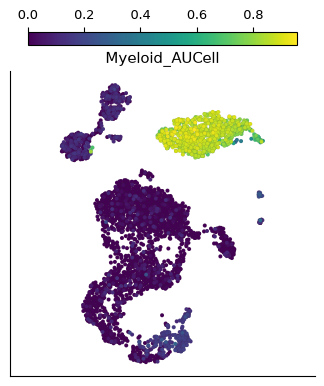

PlotResult(axes=1, tables=0, legends=1, scales=1, owns_figure=True, rendered=True)

In [6]:
myeloid = ds.get_enrichment(
    'pbmc_aucell',
    sources=['Myeloid'],
)
myeloid_scores = myeloid.data.compute().ravel()

ds.cells.insert(
    'Myeloid_AUCell',
    myeloid_scores,
    key=myeloid.cell_key,
    overwrite=True,
)
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='Myeloid_AUCell',
    sort_values=True,
)

In [7]:
ds.get_enrichment('pbmc_waggr').storage_path

'RNA/enrichment/pbmc_waggr'